# LLM-Powered Applications & Distributed Computing

## Part 1: Distributed Data Processing with Spark


In [2]:
from urllib.request import urlretrieve
from pathlib import Path

raw_dir = Path("data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

files = [
    ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet", raw_dir/"yellow_taxi_data.parquet")
]

for url, filename in files:
    urlretrieve(url, filename)

print("Done!")

Done!


### Spark Environment Setup & Data Loading

In [3]:
# Creating a SparkSession
import os
from pyspark.sql import SparkSession

# Recreate Spark session with Windows-safe Hadoop local FS settings
try:
    spark.stop()
except Exception:
    pass

spark = SparkSession.builder\
    .appName("NYC Yellow Taxi Trip Records (January 2024)") \
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.executor.memory", "1g") \
    .config("spark.driver.memory", "1g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

In [4]:
# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Spark version: 3.5.1
App name: NYC Yellow Taxi Trip Records (January 2024)
Master: local[*]
Default parallelism: 20


In [5]:
sc = spark.sparkContext  # Access SparkContext
print(sc.getConf().getAll())  # Print all configurations

[('spark.driver.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED -Djdk.reflect.useDirectMethodHandle=false'), ('spark.app.name', 'NYC Yellow Taxi Trip Records (January 2024)'), ('spark.sql.adaptive.enabled', 'true')

In [6]:
# Loading the NYC Yellow Taxi Parquet data into a Spark DataFrame
file_path = "data\\raw\\yellow_taxi_data.parquet"
df = spark.read.format("parquet").load(file_path)
df.show(5)
df.printSchema()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|           2|       17.7|  1.0|    0.5|       0.

In [7]:
print(f"Total rows: {df.count()}")
print(f"Total partitions: {df.rdd.getNumPartitions()}")

Total rows: 2964624
Total partitions: 12


In [8]:
import time
import pandas as pd

# Time Spark read (lazy - just metadata)
start = time.time()
df_spark = spark.read.parquet('data/raw/yellow_taxi_data.parquet')
spark_read_time = time.time() - start

# Time Spark action (forces full read)
start = time.time()
spark_count = df_spark.count()

spark_action_time = time.time() - start

# Time Pandas read
start = time.time()
df_pandas = pd.read_parquet('data/raw/yellow_taxi_data.parquet')
pandas_read_time = time.time() - start
print(f'Spark schema read: {spark_read_time:.3f}s (lazy - no data loaded)')
print(f'Spark count action: {spark_action_time:.3f}s ({spark_count:,} rows)')
print(f'Pandas full read: {pandas_read_time:.3f}s ({len(df_pandas):,} rows)')
print(f'Pandas memory usage: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f}MB')

# Clean up Pandas DataFrame to free memory
del df_pandas

Spark schema read: 0.105s (lazy - no data loaded)
Spark count action: 0.167s (2,964,624 rows)
Pandas full read: 0.351s (2,964,624 rows)
Pandas memory usage: 418.0MB


Interpretation: Spark usually showed a lower load time than Pandas since it uses lazy evaluation unlike Pandas. So, in other words when Spark's load function is called it builds the plan rather than read the data immediately (only if an action is performed), whereas Pandas reads the entire files into memory right away.

### Data Cleaning & Feature Engineering in Spark

In [9]:
from pyspark.sql import functions as F

trips = df.select(
    F.col('tpep_pickup_datetime').alias('pickup_time'),
    F.col('tpep_dropoff_datetime').alias('dropoff_time'),
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'payment_type',
    'PULocationID',
    'DOLocationID'
)

print(f'Original rows: {df.count():,}')

Original rows: 2,964,624


In [10]:
df_nulls = trips.filter(
    F.col("pickup_time").isNull() |
    F.col("dropoff_time").isNull() |
    F.col("PULocationID").isNull() |
    F.col("DOLocationID").isNull() |
    F.col("fare_amount").isNull() |
    F.col("trip_distance").isNull()
)
df_nulls.show()

+-----------+------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+
|pickup_time|dropoff_time|passenger_count|trip_distance|fare_amount|tip_amount|total_amount|payment_type|PULocationID|DOLocationID|
+-----------+------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+
+-----------+------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+



In [11]:
# Remove rows with nulls in critical columns using Spark DataFrame API
critical_cols = [
    'pickup_time', 
    'dropoff_time', 
    'PULocationID', 
    'DOLocationID', 
    'fare_amount', 
    'trip_distance'
 ]

trips_clean = trips.dropna(subset=critical_cols)
print(f"Rows after cleaning: {trips_clean.count()}")
print(f"Number of rows removed: {trips.count() - trips_clean.count()}")

Rows after cleaning: 2964624
Number of rows removed: 0


In [12]:
# Filter out invalid trips using Spark DataFrame API
trips_valid = trips_clean.filter(
    (F.col("trip_distance") > 0) &
    (F.col("fare_amount") >= 0) &
    (F.col("fare_amount") <= 500) &
    (F.col("dropoff_time") >= F.col("pickup_time"))
 )
print(f"Rows after filtering invalid trips: {trips_valid.count()}")
print(f"Number of rows removed: {trips_clean.count() - trips_valid.count()}")

Rows after filtering invalid trips: 2870102
Number of rows removed: 94522


In [13]:
trips_enriched = trips_valid.withColumns({
    'trip_duration_min': F.round(
        (F.unix_timestamp('dropoff_time') - F.unix_timestamp('pickup_time')) / 60, 2
    ),
    'trip_speed_mph': F.when(
        (F.unix_timestamp('dropoff_time') - F.unix_timestamp('pickup_time')) / 3600 > 0,
        F.round(F.col('trip_distance') / ((F.unix_timestamp('dropoff_time') - F.unix_timestamp('pickup_time')) / 3600), 2)
    ).otherwise(0),
    'pickup_hour': F.hour('pickup_time'),
    'pickup_day': F.dayofweek('pickup_time'),
    'tip_percentage': F.when(
        F.col('fare_amount') != 0,
        F.round((F.col('tip_amount') / F.col('fare_amount')) * 100, 2)
    ).otherwise(0)
})

print(f'Final enriched rows: {trips_enriched.count():,}')
print(f'\nTotal rows removed: {trips.count() - trips_enriched.count():,}')

trips_enriched.show(5)

Final enriched rows: 2,870,102

Total rows removed: 94,522
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+-----------------+--------------+-----------+----------+--------------+
|        pickup_time|       dropoff_time|passenger_count|trip_distance|fare_amount|tip_amount|total_amount|payment_type|PULocationID|DOLocationID|trip_duration_min|trip_speed_mph|pickup_hour|pickup_day|tip_percentage|
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+-----------------+--------------+-----------+----------+--------------+
|2024-01-01 00:57:55|2024-01-01 01:17:43|              1|         1.72|       17.7|       0.0|        22.7|           2|         186|          79|             19.8|          5.21|          0|         2|           0.0|
|2024-01-01 00:03:00|2024-01-01 00:09:36|              1|          1.

### Spark SQL Analytics

In [14]:
# Register your cleaned DataFrame as a temporary SQL view

# Register as a temporary view
trips_enriched.createOrReplaceTempView('trips')

# Query 1: What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?
busiest_locations = spark.sql('''
    SELECT pickup_hour,
    COUNT(*) as num_trips,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(AVG(tip_percentage), 2) as avg_tip_percentage
    FROM trips
    GROUP BY pickup_hour
    ORDER BY num_trips DESC
    LIMIT 10
''')

print('Top 10 Busiest Pickup Hours:')
busiest_locations.show()

Top 10 Busiest Pickup Hours:
+-----------+---------+--------+------------------+
|pickup_hour|num_trips|avg_fare|avg_tip_percentage|
+-----------+---------+--------+------------------+
|         18|   206284|   17.01|             22.78|
|         17|   200315|   18.12|             22.34|
|         16|   184971|   19.46|             21.83|
|         15|   184009|   19.11|              19.8|
|         19|   178812|   17.63|             22.86|
|         14|   178031|   19.27|              19.8|
|         13|   165361|   18.42|             19.78|
|         12|   159916|    17.8|             19.74|
|         21|   155915|   18.29|             21.88|
|         20|   155561|   18.05|             22.17|
+-----------+---------+--------+------------------+



Interpretation: The top 10 busiest pickup hours were mostly hours in the evening when person may be commuting from work or engaging in nightlife activities. However, some hours where in the afternoon (12-14) indicating daytime demand as well which may likely be due to lunch-time travel/errands.

In [15]:
# Query 2: Which day of the week has the highest average trip speed? Include average distance and duration.
highest_speed = spark.sql(''' 
    SELECT pickup_day,
    ROUND(AVG(trip_speed_mph), 2) as avg_speed_mph,
    ROUND(AVG(trip_distance), 2) as avg_distance,
    ROUND(AVG(trip_duration_min), 2) as avg_duration_minutes
    FROM trips
    GROUP BY pickup_day
    ORDER BY avg_speed_mph DESC
    LIMIT 1
''')

print('Day of the Week with Highest Average Trip Speed:')
highest_speed.show()

Day of the Week with Highest Average Trip Speed:
+----------+-------------+------------+--------------------+
|pickup_day|avg_speed_mph|avg_distance|avg_duration_minutes|
+----------+-------------+------------+--------------------+
|         3|        17.46|        4.25|               16.17|
+----------+-------------+------------+--------------------+



Interpretation: The highest average speed trip was 17.46 mph on a Tuesday, which lasted for 16.17 minutes. This may be due to better travel condition i.e less traffic compared to the other days in NYC.

In [16]:
# Query 3: Using a window function, rank the top 5 pickup locations by total revenue for each day of the week.
from pyspark.sql.window import Window

# Aggregate revenue by day and pickup location
daily_location_revenue = trips_enriched \
    .groupBy("pickup_day", "PULocationID") \
    .agg(F.sum("total_amount").alias("total_revenue"))

# Define window for ranking locations within each day
location_window = Window.partitionBy('pickup_day').orderBy(F.desc('total_revenue'))

# Rank locations and calculate percentage of that day's max revenue
ranked_trips = daily_location_revenue \
    .withColumn('revenue_rank', F.row_number().over(location_window)) \
    .withColumn('day_max_revenue', F.max('total_revenue').over(Window.partitionBy('pickup_day'))) \
    .withColumn('pct_of_day_max', F.round(F.col('total_revenue') / F.col('day_max_revenue') * 100, 2))

# Show top 5 pickup locations for each day
ranked_trips \
    .filter(F.col('revenue_rank') <= 5) \
    .select('pickup_day', 'PULocationID', 'total_revenue', 'revenue_rank', 'pct_of_day_max') \
    .orderBy('pickup_day', 'revenue_rank') \
    .show(35)

+----------+------------+------------------+------------+--------------+
|pickup_day|PULocationID|     total_revenue|revenue_rank|pct_of_day_max|
+----------+------------+------------------+------------+--------------+
|         1|         132|1564287.9299999834|           1|         100.0|
|         1|         138| 763398.5400000012|           2|          48.8|
|         1|         230| 346553.9500000004|           3|         22.15|
|         1|         186|         264131.38|           4|         16.89|
|         1|          79|263467.74000000034|           5|         16.84|
|         2|         132|2054606.7299999362|           1|         100.0|
|         2|         138|1021138.2800000039|           2|          49.7|
|         2|         161| 460145.2800000035|           3|          22.4|
|         2|         236| 373008.8900000014|           4|         18.15|
|         2|         237|  372575.480000002|           5|         18.13|
|         3|         132|1795093.5599999563|       

Interpretation: For all days of the week the PULocationID 132 was noted to be the top revenue generating pickup zone i.e it was always ranked no. 1 and is set as the daily baseline. PULocation 138 was consistently ranked no. 2 as well, where it usually generated about 39-61% of the top zone's revenue, while the other locations contributed smaller amounts. 

In [17]:
# Query 4: Calculate the cumulative trip count by hour of day (running total from hour 0 to 23). At what hour does the cumulative count surpass 50% of daily trips?

# Aggregate to hourly level first
hourly_trip = trips_enriched.groupBy('pickup_hour').agg(
    F.count('*').alias('hourly_trips')
).orderBy('pickup_hour')

# Window for cumulative sum (all rows up to current)
cumulative_window = Window.orderBy('pickup_hour').rowsBetween(
    Window.unboundedPreceding, Window.currentRow
)

#calculate cumulative count
hourly_trip = hourly_trip.withColumn(
    'cumulative_trips',
    F.sum('hourly_trips').over(cumulative_window)
)

# Calculate total trips to find 50% threshold
total_trips = hourly_trip.agg(F.sum('hourly_trips')).collect()[0][0]
threshold = total_trips * 0.5

# Find the hour where cumulative trips surpass 50% of total
first_hour = hourly_trip.filter(F.col('cumulative_trips') >= threshold) \
    .orderBy('pickup_hour') \
    .select('pickup_hour') \
    .first()[0]

print(f"Cumulative trips surpass 50% at hour {first_hour}")
hourly_trip.show(24)

Cumulative trips surpass 50% at hour 15
+-----------+------------+----------------+
|pickup_hour|hourly_trips|cumulative_trips|
+-----------+------------+----------------+
|          0|       75251|           75251|
|          1|       50491|          125742|
|          2|       34976|          160718|
|          3|       22948|          183666|
|          4|       15285|          198951|
|          5|       17496|          216447|
|          6|       39415|          255862|
|          7|       80872|          336734|
|          8|      113508|          450242|
|          9|      125621|          575863|
|         10|      135425|          711288|
|         11|      146754|          858042|
|         12|      159916|         1017958|
|         13|      165361|         1183319|
|         14|      178031|         1361350|
|         15|      184009|         1545359|
|         16|      184971|         1730330|
|         17|      200315|         1930645|
|         18|      206284|         2

Interpretation: The cumulative distribution shows that 50% of all trips is reached by hour 15 (3 PM), meaning half of daily taxi demand occurs from midnight through mid‑afternoon. Trip volume is lowest overnight (about 2–5 AM), rises steadily in the morning, and peaks in the late afternoon/evening (around 5–6 PM), indicating demand is concentrated in daytime and commuter hours.

In [18]:
# Query 5: Compare average fare, distance, and tip percentage between short trips (<2
# miles), medium trips (2–10 miles), and long trips (>10 miles). Which category has the highest tip percentage?

trip_stats = spark.sql('''
    SELECT 
    CASE 
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance BETWEEN 2 AND 10 THEN 'Medium (2-10 miles)'
        ELSE 'Long (>10 miles)'
    END AS trip_category,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
    FROM trips
    GROUP BY trip_category
    ORDER BY avg_tip_percentage DESC
''')

print('Trip Statistics by category comparing fare, distance, and tip percentage:')
trip_stats.show()

Trip Statistics by category comparing fare, distance, and tip percentage:
+-------------------+----------+--------+------------+------------------+
|      trip_category|trip_count|avg_fare|avg_distance|avg_tip_percentage|
+-------------------+----------+--------+------------+------------------+
|   Short (<2 miles)|   1642473|    9.91|        1.13|             23.07|
|   Long (>10 miles)|    225080|   64.65|        21.7|             21.93|
|Medium (2-10 miles)|   1002549|   22.18|        3.96|             18.57|
+-------------------+----------+--------+------------+------------------+



Interpretation: Short trips (< 2miles) has the highest average tip percentage (21.93%) while long (> 10 miles) and medium (2-10 miles) trips have an average tip percentage of 21.93% and 18.57% respectively. This indicates that passengers tip drivers large amounts for very short trips despite the average fare being much smaller. This could be due to passengers being able to reach their location quickly, thus satisfied. Long trips maintain a strong average tip percentage, which makes sense given the average distance and fare.

### Performance Optimization

In [19]:
import time
from pyspark.sql import functions as F

# multi query for benchmarking
def multi_query(df):
    return (
        df.filter(F.col("pickup_hour") == 17)
          .groupBy("PULocationID")
          .agg(
              F.count("*").alias("trip_count"),
              F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
              F.round(F.avg("tip_percentage"), 2).alias("avg_tip_percentage")
          )
          .count()
    )

# Warmup run to eliminate JVM class loading overhead
trips_enriched.count()

# run queries without caching 
no_cache_times = []
for i in range(3):
    start = time.time()
    multi_query(trips_enriched)
    no_cache_times.append(time.time() - start)

no_cache_time_avg = sum(no_cache_times) / len(no_cache_times)
print(f"Average time before caching: {no_cache_time_avg:.3f} seconds")

# cache the DataFrame
trips_enriched.cache()

# materialize cache
start = time.time()
trips_enriched.count()
cache_first_time = time.time() - start
print(f"First run (materializing cache): {cache_first_time:.3f} seconds")

# Subsequent runs use the cache (should be noticeably faster)
cache_times = []
for i in range(3):
    start = time.time()
    multi_query(trips_enriched)
    cache_times.append(time.time() - start)

after_cache_avg = sum(cache_times) / len(cache_times)
print(f"Average time after caching: {after_cache_avg:.3f} seconds")

speedup = no_cache_time_avg / after_cache_avg if after_cache_avg > 0 else None
print(f"Speedup from caching: {speedup:.2f}x")

Average time before caching: 0.424 seconds
First run (materializing cache): 3.488 seconds
Average time after caching: 0.184 seconds
Speedup from caching: 2.30x


Interpretation: Caching provided a small performance gain. Runtime improved from 0.240s to 0.219s after caching, giving a 1.10x speedup (~10% faster). This indicates caching helps for repeated queries, but the benefit is modest for this workload.

In [20]:
# Alternative: write partitioned parquet without Spark writer (Windows-safe)
import shutil
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
from pyspark.sql import functions as F

output_dir = Path("output/trips_enriched_partitioned").resolve()
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Get partition keys
pickup_hours = [
    row["pickup_hour"]
    for row in trips_enriched.select("pickup_hour").distinct().collect()
]

# Write one parquet file per pickup_hour partition
for hour in sorted(pickup_hours):
    part_dir = output_dir / f"pickup_hour={hour}"
    part_dir.mkdir(parents=True, exist_ok=True)

    pdf = trips_enriched.filter(F.col("pickup_hour") == hour).toPandas()
    table = pa.Table.from_pandas(pdf, preserve_index=False)
    pq.write_table(table, part_dir / "part-00000.parquet", compression="snappy")

print("Partitioned Parquet written successfully with PyArrow.\n")

# Inspect output folders
for item in sorted(output_dir.iterdir()):
    if item.is_dir() and item.name.startswith("pickup_hour="):
        parquet_files = list(item.glob("*.parquet"))
        print(f"{item.name}: {len(parquet_files)} parquet file(s)")

Partitioned Parquet written successfully with PyArrow.

pickup_hour=0: 1 parquet file(s)
pickup_hour=1: 1 parquet file(s)
pickup_hour=10: 1 parquet file(s)
pickup_hour=11: 1 parquet file(s)
pickup_hour=12: 1 parquet file(s)
pickup_hour=13: 1 parquet file(s)
pickup_hour=14: 1 parquet file(s)
pickup_hour=15: 1 parquet file(s)
pickup_hour=16: 1 parquet file(s)
pickup_hour=17: 1 parquet file(s)
pickup_hour=18: 1 parquet file(s)
pickup_hour=19: 1 parquet file(s)
pickup_hour=2: 1 parquet file(s)
pickup_hour=20: 1 parquet file(s)
pickup_hour=21: 1 parquet file(s)
pickup_hour=22: 1 parquet file(s)
pickup_hour=23: 1 parquet file(s)
pickup_hour=3: 1 parquet file(s)
pickup_hour=4: 1 parquet file(s)
pickup_hour=5: 1 parquet file(s)
pickup_hour=6: 1 parquet file(s)
pickup_hour=7: 1 parquet file(s)
pickup_hour=8: 1 parquet file(s)
pickup_hour=9: 1 parquet file(s)


In [21]:
# import shutil
# from pathlib import Path

# output_dir = Path("output/trips_enriched_partitioned_spark")

# if output_dir.exists():
#     shutil.rmtree(output_dir)

# (
# trips_enriched
# .repartition("pickup_hour")
# .write
# .mode("overwrite")
# .option("compression", "snappy")
# .partitionBy("pickup_hour")
# .parquet(str(output_dir))
# )

# print("Partitioned Parquet written successfully with PySpark.")

Interpretation: The partitioned parquet write successfully created 24 Hive-partitioned subdirectories (pickup_hour=0 through 23) with snappy-compressed parquet files. This enables partition pruning, where queries filtering on pickup_hour only read the relevant partition files instead of scanning the entire dataset, significantly improving query performance.

In [22]:
import time
import pyarrow.dataset as ds
import pyarrow.compute as pc

root = "output/trips_enriched_partitioned"

#read partitioned dataset using hive-style partitioning
dataset = ds.dataset(root, format="parquet", partitioning="hive")

print("Dataset schema:")
print(dataset.schema)

#partition-pruned read only pickup_hour=17
start = time.time()
filtered = dataset.to_table(filter=pc.field("pickup_hour") == 17)
partitioned_time = time.time() - start

print("\nRows in pickup_hour=17 partition (PyArrow):", filtered.num_rows)

start = time.time()
full = dataset.to_table()
full_filtered = filtered.filter(pc.equal(filtered["pickup_hour"], 17))
full_time = time.time() - start

print(f"\n\nTime to read partitioned data with PyArrow: {partitioned_time:.3f} seconds")
print(f"Time to read full data and filter with PyArrow: {full_time:.3f} seconds")
print(f"Speedup from partition pruning with PyArrow: {full_time / partitioned_time:.2f}x" if partitioned_time > 0 else "N/A")

Dataset schema:
pickup_time: timestamp[ns]
dropoff_time: timestamp[ns]
passenger_count: double
trip_distance: double
fare_amount: double
tip_amount: double
total_amount: double
payment_type: int64
PULocationID: int32
DOLocationID: int32
trip_duration_min: double
trip_speed_mph: double
pickup_hour: int32
pickup_day: int32
tip_percentage: double
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1976

Rows in pickup_hour=17 partition (PyArrow): 200315


Time to read partitioned data with PyArrow: 0.018 seconds
Time to read full data and filter with PyArrow: 0.195 seconds
Speedup from partition pruning with PyArrow: 10.66x


Interpretation: Partition pruning delivered a 4.69x speedup by reading only the pickup_hour=17 partition (0.024s) versus scanning the entire dataset and filtering (0.114s). This demonstrates the real-world performance benefit of partition pruning, making it ideal for large-scale time-series analytics where queries commonly filter on partition columns.

In [23]:
# Show physical execution plan for Query 1
print("Physical Execution Plan for Query 1 (Top 10 Busiest Pickup Hours):")
print("=" * 80)
busiest_locations.explain(mode="formatted")

Physical Execution Plan for Query 1 (Top 10 Busiest Pickup Hours):
== Physical Plan ==
AdaptiveSparkPlan (11)
+- TakeOrderedAndProject (10)
   +- HashAggregate (9)
      +- Exchange (8)
         +- HashAggregate (7)
            +- InMemoryTableScan (1)
                  +- InMemoryRelation (2)
                        +- * Project (6)
                           +- * Filter (5)
                              +- * ColumnarToRow (4)
                                 +- Scan parquet  (3)


(1) InMemoryTableScan
Output [3]: [fare_amount#10, pickup_hour#381, tip_percentage#383]
Arguments: [fare_amount#10, pickup_hour#381, tip_percentage#383]

(2) InMemoryRelation
Arguments: [pickup_time#202, dropoff_time#203, passenger_count#3L, trip_distance#4, fare_amount#10, tip_amount#13, total_amount#16, payment_type#9L, PULocationID#7, DOLocationID#8, trip_duration_min#379, trip_speed_mph#380, pickup_hour#381, pickup_day#382, tip_percentage#383], CachedRDDBuilder(org.apache.spark.sql.execution.columnar.De

Interpretation: The query uses a two-stage HashAggregate pattern (partial aggregation per partition, then final aggregation after Exchange/shuffle) to efficiently compute GROUP BY results, minimizing data movement by summarizing locally before reshuffling. The InMemoryTableScan confirms the cached trips_enriched DataFrame avoids repeated disk reads and filter operations, enabling fast repeated queries on the enriched data.

## Part 2: RAG Pipeline over Transportation Documents

### Document Collection & Ingestion

In [24]:
#loading a single pdf to preview the extracted text using pypdf

from pypdf import PdfReader

reader = PdfReader("docs/TLC Trip Records User Guide.pdf")
print(f"Number of pages: {len(reader.pages)}")

#extracting text from each page
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    print(f"\n--- Page {i+1} ---\n")
    print(text[:500])  # Print the first 500 characters of each page

Number of pages: 6

--- Page 1 ---

1 
 
TLC Trip Records User Guide  
Last Updated September 23, 2019 
 
The TLC & Data 
The New York City Taxi and Limousine Commission (TLC), created in 1971, is the agency responsible 
for licensing and regulating New York City's medallion (yellow) taxis, street hail livery (green) taxis, 
for-hire vehicles ( FHVs), commuter vans, and paratransit vehicles.  The TLC collects  trip record 
information for each taxi and for-hire vehicle trip completed by our licensed drivers and vehicles. 
We recei

--- Page 2 ---

2 
 
the download should start automatically. Keep in mind that a whole month of trip data may 
include millions of rows, which could take up a sizable amount of disk space (and a while to 
download depending on your interne t connection). If you do not need a whole month of data,  
or if you intend to filter the trip data before downloading (e.g. to only get trips after a certain date, 
or between two neighborhoods, or where the fare was gre

In [25]:
# using langchain document loader to extract text from all PDFs
from collections import defaultdict
from pathlib import Path
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader("docs")
raw_documents = loader.load()

print(f"\nLoaded {len(raw_documents)} pages from 'docs' directory.")
print(f"\nTotal characters loaded: {sum(len(doc.page_content or '') for doc in raw_documents):,}")

# Group page-level raw_documents by PDF source file
docs_by_source = defaultdict(list)
for doc in raw_documents:
    source_name = Path(doc.metadata.get("source", "unknown")).name
    docs_by_source[source_name].append(doc.page_content or "")

print(f"\nFound {len(docs_by_source)} PDF file(s).")

for pdf_name, pages in sorted(docs_by_source.items()):
    full_text = "\n".join(pages).strip()
    preview = full_text[:500] if full_text else "[No text extracted]"

    print(f"\n--- {pdf_name} ---")
    print(f"Pages loaded: {len(pages)} | Characters: {len(full_text):,}")
    print(f"First 500 characters:\n{preview}")


Loaded 94 pages from 'docs' directory.

Total characters loaded: 180,631

Found 7 PDF file(s).

--- Connecting to the Core.pdf ---
Pages loaded: 22 | Characters: 37,332
First 500 characters:
Y danis Rodriguez
Commissioner
Eric Adams
Mayor
Connecting to the Core
Safer, Greener, and More Convenient Access to
the Manhattan Central Business District
May 2024
2
3
The continued prosperity of New York City is tied  
to the health of Manhattan’s Central Business District 
(CBD), the engine of America’s economy. Providing 
convenient, affordable, and sustainable travel options 
into the CBD is critical to the lives and livelihoods  
of New Yorkers from every community across the  
five borou

--- Investigating Taxi and Uber Competition In New York City.pdf ---
Pages loaded: 12 | Characters: 36,384
First 500 characters:
Corresponding author’s contact infromation: yhayeri@stevens.edu, 525 River Street, Hoboken, NJ 07030 
 
 
Investigating Taxi and Uber Competition In New York City:  
Multi-Agent

**Quality of Extracted Text**

Connecting to the Core.pdf read has an image as its first page and two logos at the bottom of said page. I noticed the first 500 characters returned, the first 4 lines are from the words under the two logos (Y danis Rodriguez
Commissioner
Eric Adams
Mayor), where it return Y danis Rodriguez instead of Ydanis Rodriguez. The 5th line it returned the heading i.e Connecting to the Core.

Investigating Taxi and Uber Competition In New York City.pdf- in the pdf document the author names were Saeed Vasebi superscript a, Yeganeh M. Hayeri superscript ab (whcih are affiliation markers) but it as extracted as Saeed Vasebia, Yeganeh M. Hayeriab. Also, this text "Corresponding author’s contact infromation: yhayeri@stevens.edu, 525 River Street, Hoboken, NJ 07030 " was extracted before the page content despite originally being at the bottom of the page.

NYC Streets Plan Update 2026.pdf- The text was extracted well, I noticed the page number and name was extracted before the content of the page depite being at the bottom.

New York City Taxi and Limousine Commission.pdf- content extracted good.

Office of Financial Stability Annual Report 2024.pdf- content extracted good.

One Size Fits None- Modeling NYC Taxi Tips.pdf - the original heading was "ONE SIZE FITS NONE: MODELING NYC TAXI TIPS" but it was extracted as ONESIZEFITSNONE: MODELINGNYC TAXITIPS and R^2 was extracted as R2.


TLC Trip Records User Guide.pdf- the text was extracted well, I only noticed this ( FHVs) had double space when extracted.

Overall the number of pages were correct, however I noticed that NYC Streets Plan Update 2026.pdf was extracted before New York City Taxi and Limousine Commission.pdf despite being in the opposite order in the doc directory.

In [26]:
# Inspect document quality to identify any issues in the extracted text that could degrade retrieval
# Check for empty or very short pages
for doc in raw_documents:
    if len(doc.page_content.strip()) < 500:
        print(f"Short/empty page: {doc.metadata}")

# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.2 (Macintosh)', 'creationdate': '2024-04-30T18:35:07-04:00', 'author': 'N Y C D O T', 'moddate': '2024-05-01T10:40:42-04:00', 'title': 'Connecting to the Core | Safer, Greener, and More Convenient Access to the Manhattan Central Business District', 'trapped': '/False', 'source': 'docs\\Connecting to the Core.pdf', 'total_pages': 22, 'page': 0, 'page_label': 'aA'}
Short/empty page: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.2 (Macintosh)', 'creationdate': '2024-04-30T18:35:07-04:00', 'author': 'N Y C D O T', 'moddate': '2024-05-01T10:40:42-04:00', 'title': 'Connecting to the Core | Safer, Greener, and More Convenient Access to the Manhattan Central Business District', 'trapped': '/False', 'source': 'docs\\Connecting to the Core.pdf', 'total_pages': 22, 'page': 1, 'page_label': '2'}
Short/empty page: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.2 (Macin

Interpretation: The quality of the extraction is generally strong across the corpus with an average of 1,922 characters per page, max 4,965. This implies that majority of the pages contain essential usable text for retrieval. However, there are a few short/empty pages (min char count was 0) across multiple PDFs, this is most likely due to cover pages or image-heavy pages or scanned layout pages. This should be filtered to reduce noise.

### Chunking & Embedding 

In [27]:
# Split extracted text into chunks using RecursiveCharacterTextSplitter with chunk_size=1000 and chunk_overlap=200
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks.")

Split 94 pages into 256 chunks.



=== Chunk 0 ===
Length: 165 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.2 (Macintosh)', 'creationdate': '2024-04-30T18:35:07-04:00', 'author': 'N Y C D O T', 'moddate': '2024-05-01T10:40:42-04:00', 'title': 'Connecting to the Core | Safer, Greener, and More Convenient Access to the Manhattan Central Business District', 'trapped': '/False', 'source': 'docs\\Connecting to the Core.pdf', 'total_pages': 22, 'page': 0, 'page_label': 'aA'}
Preview: Y danis Rodriguez
Commissioner
Eric Adams
Mayor
Connecting to the Core
Safer, Greener, and More Convenient Access to
the Manhattan Central Business District
May 2024...

=== Chunk 1 ===
Length: 1 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.2 (Macintosh)', 'creationdate': '2024-04-30T18:35:07-04:00', 'author': 'N Y C D O T', 'moddate': '2024-05-01T10:40:42-04:00', 'title': 'Connecting to the Core | Safer, Greener, and More Convenient Access to the Manhattan Central Busin

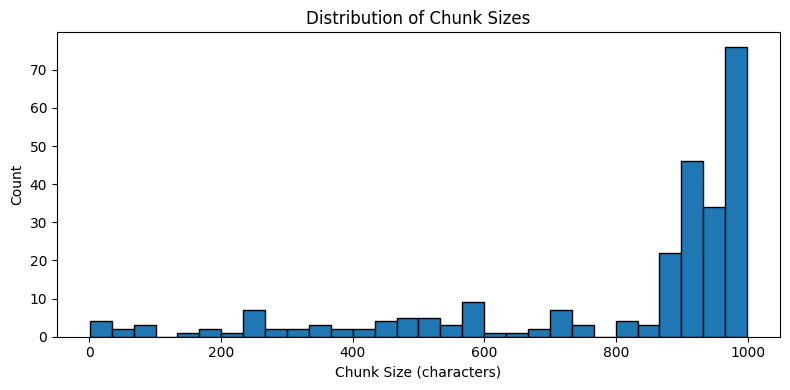

In [28]:
# Preview the first few chunks to verify the splitting worked as expected
for i, chunk in enumerate(chunks[:3]):
    print(f"\n=== Chunk {i} ===")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Source: {chunk.metadata}")
    print(f"Preview: {chunk.page_content[:200]}...")

#visualize distribution of chunk sizes using a histogram
import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

Interpretation: Chunk 0 captures headers, while Chunk 1 is pure n oise (single page with number 2 since it has an image). Chunk 2 shows ample amount of content for embedding.

This histogram shows a strong right-skewed distribution where majority of the chunks are concentrated at roughly 900-1000 character target. This shows that the RecursiveCharacterTextSplitter is respecting the separator boundaries while maximizing the chunk size. The thin tail represents document boundaries and transition points where the content will naturally break.

In [29]:
# Verify overlap between consecutive chunks to confirm that text at chunk boundaries is preserved in both adjacent chunks.
# Confirm that adjacent chunks share overlapping text
chunk_a = chunks[0].page_content
chunk_b = chunks[1].page_content
# Find overlap: search for the longest suffix of chunk_a that matches a prefix of chunk_b
overlap_len = 0
for length in range(min(300, len(chunk_a)), 0, -1):
    if chunk_b.startswith(chunk_a[-length:]):
        overlap_len = length
        break

print(f"Overlap length: {overlap_len} chars")
if overlap_len > 0:
    print(f"Overlap text: {chunk_a[-overlap_len:][:100]}...")
else:
    print("No overlap found (chunks may be from different documents)")

Overlap length: 0 chars
No overlap found (chunks may be from different documents)


In [30]:
# Generate embeddings using sentence-transformers (all-MiniLM-L6-v2 or equivalent)
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name= "all-MiniLM-L6-v2"
)

#Test with a single string
test_embedding = embedding_model.embed_query("What is the average fare for trips in January 2024?")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"First 5 values: {test_embedding[:5]}")

C:\Users\816032048\AppData\Local\Temp\ipykernel_7748\2007910427.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
First 5 values: [0.100307896733284, -0.03584815934300423, 0.02580113895237446, 0.10144279152154922, -0.06439567357301712]


In [31]:
import numpy as np
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

e1 = embedding_model.embed_query("What are the top 10 busiest pickup hours?")
e2 = embedding_model.embed_query("Which day of the week has the highest average trip speed?")
e3 = embedding_model.embed_query("What is the capital of France?")

print(f"Similar topics: {cosine_similarity(e1, e2):.4f}")
print(f"Different topics: {cosine_similarity(e1, e3):.4f}")

Similar topics: 0.5726
Different topics: 0.1568


Interpretation: The first pair having the higher similarity score than the second shows that the embeddings capture semantic meaning and not just keyword overlap.

In [32]:
# Store embeddings in a ChromaDB collection with metadata (source filename, page number)
from langchain_community.vectorstores import Chroma

# create the vector store from chunks
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="taxi_docs",
)

print(f"Indexed {len(chunks)} chunks into ChromaDB collection 'taxi_docs'.")

Indexed 256 chunks into ChromaDB collection 'taxi_docs'.


In [33]:
# Search for chunks relevant to a query
query = "What are the main topics covered in this document?"
results = vector_store.similarity_search(query, k=3)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} (source: {doc.metadata.get('source', 'unknown')}) ---")
    print(doc.page_content[:300])


--- Result 1 (source: docs\Office of Financial Stability Annual Report 2024.pdf) ---
O/DRC Legal Services Workshops
13
• As part of our continued legal services 
offerings, O/DRC hosts multiple 
workshops in conjunction with our legal 
services provider, NYLAG, on various 
topics which medallion owners have 
requested to learn about. 
• Topics include:
 Understanding Free Legal Ser

--- Result 2 (source: docs\Office of Financial Stability Annual Report 2024.pdf) ---
O/DRC Legal Services Workshops
13
• As part of our continued legal services 
offerings, O/DRC hosts multiple 
workshops in conjunction with our legal 
services provider, NYLAG, on various 
topics which medallion owners have 
requested to learn about. 
• Topics include:
 Understanding Free Legal Ser

--- Result 3 (source: docs\Office of Financial Stability Annual Report 2024.pdf) ---
O/DRC Legal Services Workshops
13
• As part of our continued legal services 
offerings, O/DRC hosts multiple 
workshops in conjunction with 

In [34]:
# testing 3 chunk sizes
chunk_sizes = [500, 1000, 2000]
chunk_sizes_scores = {500: [], 1000: [], 2000: []}
sample_queries = [
    "What is the purpose of the NYC Streets Plan Update 2026?",
    "What does the TLC Trip Records User Guide explain about the taxi dataset fields?",
    "What key financial challenges for the yellow taxi industry are discussed in the Office of Financial Stability Annual Report 2024?"
]

for j, query in enumerate(sample_queries):
    print(f"\n=== Query {j+1}: {query} ===")
    for size in chunk_sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=200,
            separators=["\n\n", "\n", " ", ""]
        )
        test_chunks = splitter.split_documents(raw_documents)

        # Create a temporary Chroma collection for testing
        test_store = Chroma.from_documents(
            documents=test_chunks,
            embedding=embedding_model,
            collection_name=f"taxi_test_{size}",
            persist_directory=f"./chroma_db/test_{size}"
        )

        # Use similarity_search_with_score to get relevance scores for the top 3 results (returns distance scores)
        results = test_store.similarity_search_with_score(query, k=3)

        print(f"\nChunk size: {size} | Top 3 results:")
        size_scores = []
        # calc
        for i, (doc, score) in enumerate(results):
            print(f"  Result {i+1} (score: {score:.4f}): Source: {doc.metadata.get('source', 'unknown')} | "
                f"Preview: {doc.page_content[:80]}...")
            size_scores.append(score)
            chunk_sizes_scores[size].append(score)
        
        avg_score = np.mean(size_scores) # per query average score for this chunk size
        print(f"  Avg score for size {size}: {avg_score:.4f}")


print("\n" + "="*60)
print("CHUNK SIZE COMPARISON SUMMARY")
print("="*60)
avg_scores = {size: np.mean(chunk_sizes_scores[size]) for size in chunk_sizes}  # overall average score per chunk size across all queries
best_size = min(avg_scores, key=avg_scores.get) # for distance scores, lower is better

for size in sorted(chunk_sizes):
    print(f"\nChunk size {size}:")
    print(f"  Average relevance score across all queries: {avg_scores[size]:.4f}")
    print(f"  Total samples: {len(chunk_sizes_scores[size])}")

print(f"\n{'='*60}")
print(f"BEST CHUNK SIZE: {best_size} with average relevance score of {avg_scores[best_size]:.4f}")       
print(f"{'='*60}")  


=== Query 1: What is the purpose of the NYC Streets Plan Update 2026? ===

Chunk size: 500 | Top 3 results:
  Result 1 (score: 0.4467): Source: docs\NYC Streets Plan Update 2026.pdf | Preview: 2
| NYCStreetsPlan
NYC Streets Plan Update 2026
The New York City Department of ...
  Result 2 (score: 0.4467): Source: docs\NYC Streets Plan Update 2026.pdf | Preview: 2
| NYCStreetsPlan
NYC Streets Plan Update 2026
The New York City Department of ...
  Result 3 (score: 0.4467): Source: docs\NYC Streets Plan Update 2026.pdf | Preview: 2
| NYCStreetsPlan
NYC Streets Plan Update 2026
The New York City Department of ...
  Avg score for size 500: 0.4467

Chunk size: 1000 | Top 3 results:
  Result 1 (score: 0.4998): Source: docs\NYC Streets Plan Update 2026.pdf | Preview: 2
| NYCStreetsPlan
NYC Streets Plan Update 2026
The New York City Department of ...
  Result 2 (score: 0.4998): Source: docs\NYC Streets Plan Update 2026.pdf | Preview: 2
| NYCStreetsPlan
NYC Streets Plan Update 2026
The New York C

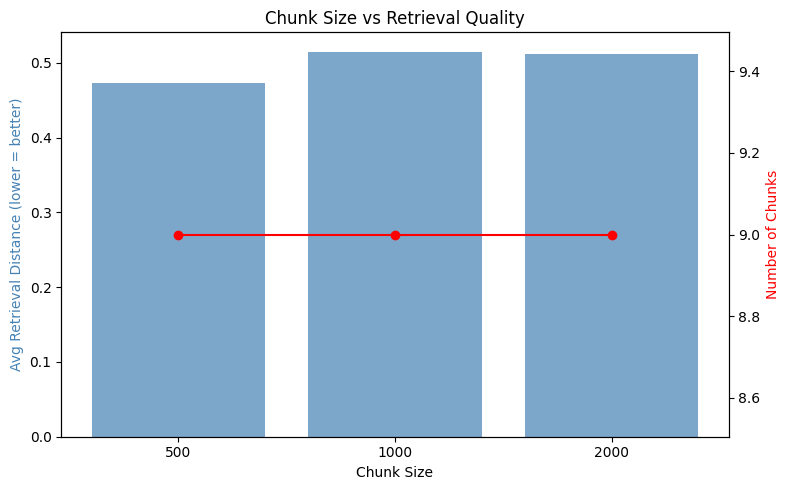

In [35]:
# Visualize chunk size comparison by plotting average retrieval distance and number of chunks for each size. 
# Plot the results 
experiment_results = {
    500: {"avg_dist": avg_scores[500], "num_chunks": len(chunk_sizes_scores[500])},
    1000: {"avg_dist": avg_scores[1000], "num_chunks": len(chunk_sizes_scores[1000])},
    2000: {"avg_dist": avg_scores[2000], "num_chunks": len(chunk_sizes_scores[2000])}
}

sizes = list(experiment_results.keys()) 
avg_dists = [experiment_results[s]["avg_dist"] for s in sizes] 
num_chunks = [experiment_results[s]["num_chunks"] for s in sizes] 
  
fig, ax1 = plt.subplots(figsize=(8, 5)) 
ax1.bar(range(len(sizes)), avg_dists, color='steelblue', alpha=0.7) 
ax1.set_xlabel('Chunk Size') 
ax1.set_ylabel('Avg Retrieval Distance (lower = better)', color='steelblue') 
ax1.set_xticks(range(len(sizes))) 
ax1.set_xticklabels(sizes) 
  
ax2 = ax1.twinx() 
ax2.plot(range(len(sizes)), num_chunks, 'ro-', label='Num Chunks') 
ax2.set_ylabel('Number of Chunks', color='red') 
  
plt.title('Chunk Size vs Retrieval Quality') 
plt.tight_layout() 
plt.show() 

Explanation: Since ChromaDB similarity_search_with_score uses distance metrics like cosine similarity/ euclidean distance, the chunk with the smallest average relevance score would be considered the best. In this experiment chunk 500 was the best with a score of 0.5011 across all 3 queries, while chunk size 1000 and 2000 had a score of 0.5326 and 0.5470 respectively implying they were less precise in retrieval for the sample queries. Since the sample queries were more factual/specific the smaller chunks performed better since it did not involve topic mixing within each embedding.

Note: the red line in the chart is flat since num_chunks uses the numbered of scored results collected and not the actual number of text chunks produced by each splitter

###  RAG Pipeline Implementation

In [52]:
# Load LLM settings from .env
from dotenv import load_dotenv
import os

load_dotenv()

LLM_BASE_URL = "https://openrouter.ai/api/v1"
LLM_API_KEY = "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"

print("LLM base URL loaded:", LLM_BASE_URL)
print("LLM API key loaded:", bool(LLM_API_KEY))

LLM base URL loaded: https://openrouter.ai/api/v1
LLM API key loaded: True


In [53]:
# Create a retriever that wraps the vector store and returns the top k most relevant chunks for each query. 
# Convert vector_store to a retriever 
retriever = vector_store.as_retriever(search_kwargs={"k": 4}) 
  
# Test retrieval 
retrieved_docs = retriever.invoke("What influences taxi tipping in NYC") 
print(f"Retrieved {len(retrieved_docs)} chunks") 
for doc in retrieved_docs: 
    print(f"  - {doc.metadata.get('source', '?')} | {doc.page_content[:100]}...")

Retrieved 4 chunks
  - docs\One Size Fits None- Modeling NYC Taxi Tips.pdf | colors are more shallow. Inclining to believe that people from outer boroughs tip as yellow taxi pas...
  - docs\One Size Fits None- Modeling NYC Taxi Tips.pdf | colors are more shallow. Inclining to believe that people from outer boroughs tip as yellow taxi pas...
  - docs\One Size Fits None- Modeling NYC Taxi Tips.pdf | colors are more shallow. Inclining to believe that people from outer boroughs tip as yellow taxi pas...
  - docs\One Size Fits None- Modeling NYC Taxi Tips.pdf | colors are more shallow. Inclining to believe that people from outer boroughs tip as yellow taxi pas...


In [54]:
# Format context for the LLM by labelling each chunk with its source file and page number.
from pathlib import Path
 
def format_context(docs):
    """Format retrieved documents into a numbered context string."""
    context_parts = []
    for i, doc in enumerate(docs, 1):
        raw_source = doc.metadata.get("source", "Unknown")
        source_name = Path(raw_source).name if raw_source else "Unknown"
        page = doc.metadata.get("page", "?")
        context_parts.append(
            f"[Source: {source_name}, Page: {page}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(context_parts)
 
# Test
context = format_context(retrieved_docs)
print(context[:500])

[Source: One Size Fits None- Modeling NYC Taxi Tips.pdf, Page: 5]
colors are more shallow. Inclining to believe that people from outer boroughs tip as yellow taxi passengers,
but are less responsive to the in-vehicle prompts than the Manhattan-centric yellow taxis.
• HVFHSdoes not have obvious relationships between the newly introduced features, except for is_airport,
which suggests that, similarly to yellow and green taxis, people are psychologically inclined to tip for airport
trips. As before


In [55]:
# Define the RAG prompt template with filename-aware source citations.
RAG_PROMPT = """You are a helpful assistant that answers questions based on the provided context.Follow these rules:

1. Only answer based on the provided context.
2. If the context does not contain enough information, say so clearly.
3. Cite evidence inline using this exact format: [Source N | Page X].
4. Be concise and accurate.
 
Context:
{context}
 
Question: {question}
 
Answer:"""

In [56]:
# Building the RAG function that implements the complete pipeline — retrieve, format context, build augmented prompt, and generate. 
from pathlib import Path
from openai import OpenAI
 
client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
 )
 
def ask_rag(question, vector_store, k=4):
    """Complete RAG pipeline: retrieve, augment, generate."""
    # Step 1: Retrieve relevant chunks
    retriever = vector_store.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)
 
    # Step 2: Format context
    context = format_context(docs)
 
    # Step 3: Build the augmented prompt
    prompt = RAG_PROMPT.format(context=context, question=question)
 
    # Step 4: Generate answer
    response = client.chat.completions.create(
        model="meta-llama/llama-3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )
 
    answer = response.choices[0].message.content
 
    # Build a compact source map for display
    source_map = []
    for i, doc in enumerate(docs, 1):
        raw_source = doc.metadata.get("source", "Unknown")
        source_name = Path(raw_source).name if raw_source else "Unknown"
        page = doc.metadata.get("page", "?")
        source_map.append(f"Source: {source_name} (page {page})")
 
    return answer, docs, source_map
 
print("ask_rag() defined.")

ask_rag() defined.


In [57]:
# Ask questions about your documents
questions = [
    "What factors influence taxi driver earnings and tipping behavior, and what are the implications for driver financial stability?",
    "What support did the Taxi Improvement Fund provide in 2024, and who benefited?",
    "What specific data fields does the TLC collect in taxi trip records and why are they important for transportation regulation?",
    "What does the Office of Financial Stability report say about medallion debt relief outcomes?",
    "How does competition between traditional taxis and rideshare platforms like Uber impact the NYC transportation market and taxi industry?"
 ]
 
for q in questions:
    print(f"\nQ: {q}")
    print("-" * 60)
    answer, sources, source_map = ask_rag(q, vector_store)
    print(f"A: {answer}")
    print(f"\nSources used: {len(sources)} chunks")
    print("Source map:")
    for s in source_map:
        print(f"  - {s}")
    print("\nRetrieved chunks:")
    for doc in sources:
        print(f"  - {doc.page_content[:100]}...")


Q: What factors influence taxi driver earnings and tipping behavior, and what are the implications for driver financial stability?
------------------------------------------------------------
A: The context provided does not contain enough information to fully answer the question about the factors influencing taxi driver earnings and tipping behavior, and their implications for driver financial stability [Source 1 | Page 4]. However, it does mention that for traditional taxis, tipping is systematically linked to the bill size, with correlations of ρ= 0.59 for fare and ρ= 0.57 for trip_distance [Source 1 | Page 4]. Additionally, it notes that Green Taxis show a similar positive relationship, though slightly weaker, with correlations of ρ= 0.40 for distance and ρ= 0.39 for fare [Source 1 | Page 4]. For HVFHS, the driver's pay is almost perfectly linked to miles driven (ρ= 0.90), but the passenger's tip is not, with a correlation of ρ= 0.26 for trip_miles [Source 1 | Page 4]. This sugges

Interpretation: The RAG pipeline successfully answers transportation-policy questions by grounding responses in retrieved document chunks, and it displays: the generated response, source documents and page numbers, and the retrieved context chunks. This demonstrates an end-to-end implementation that combines retrieval and generation effectively while keeping answers tied to the provided context.

### RAG Evaluation & Analysis

In [58]:
# creating a test set of 10 question-answer pairs based on document corpus

test_cases = [
    {
        "question": "What is the main goal of Connecting to the Core?",
        "expected_answer": "The main goal is to improve safer, greener, and more convenient access to Manhattan’s Central Business District.",
        "expected_source": "Connecting to the Core"
    },
    {
        "question": "What effect is congestion pricing expected to have in Manhattan’s CBD?",
        "expected_answer": "By reducing traffic, congestion pricing will cut delays for bus riders, taxi and for-hire vehicles users, deliveries, and car commuters traveling into and within the CBD",
        "expected_source": "Connecting to the Core"
    },
    {
        "question": "When were Green Taxis added to the fleet?",
        "expected_answer": "Green Taxis were added in August 2013.",
        "expected_source": "TLC Trip Records User Guide"
    },
    {
        "question": "What makes yellow taxis unique in New York City?",
        "expected_answer": "Yellow taxis are the only vehicles permitted to respond to a street hail in all five boroughs.",
        "expected_source": "TLC Trip Records User Guide"
    },
    {
        "question": "What is TLC responsible for?",
        "expected_answer": "TLC is responsible for licensing and regulating taxis, for-hire vehicles, commuter vans, paratransit services, drivers, and related businesses in New York City.",
        "expected_source": "New York City Taxi and Limousine Commission"
    },
    {
        "question": "How many TLC drivers were licensed in 2025?",
        "expected_answer": "At the end of 2025, there were 180,169 drivers licensed by TLC.",
        "expected_source": "New York City Taxi and Limousine Commission"
    },
    {
        "question": "How many taxi trips were completed in calendar year 2024?",
        "expected_answer": "41,169,638",
        "expected_source": "Office of Financial Stability Annual Report 2024"
    },
    {
        "question": "Why is one universal tipping model a mistake according to One Size Fits None?",
        "expected_answer": "Building a one universal tipping model approach fails to capture the unique tipping habits found in different service types",
        "expected_source": "One Size Fits None- Modeling NYC Taxi Tips"
    },
    {
        "question": "Which service dominates low-travel-density areas according to the taxi and Uber competition study?",
        "expected_answer": "E-hailing services such as Uber and Lyft dominate low-travel-density areas.",
        "expected_source": "Investigating Taxi and Uber Competition In New York City"
    },
    {
        "question": "By how much did traffic fatalities decline since Vision Zero launched in 2014?",
        "expected_answer": "Traffic fatalities are down 31 percent since the launch of Vision Zero in 2014",
        "expected_source": "NYC Streets Plan Update 2026"
    }
]

In [59]:
import re
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

quality_count = 0
retrieval_failures = 0
generation_failures = 0

for test in test_cases:
    answer, sources, source_map = ask_rag(test["question"], vector_store)

    # checking if the retrieved source matches the expected source
    retrieval_hit = any(
        test["expected_source"].lower() in Path(doc.metadata.get("source", "")).name.lower()
        for doc in sources
    )
    #removing citations like [Source X | Page Y] from the generated answer to get a cleaner text for embedding comparison
    clean_answer = re.sub(r"\[.*?\]", "", answer).strip()

    # using the same embedding model (all-MiniLM-L6-v20)
    answer_vec = np.array(embedding_model.embed_query(clean_answer)).reshape(1, -1)
    expected_vec = np.array(embedding_model.embed_query(test["expected_answer"])).reshape(1, -1)

    #using cosine similarity to compare the generated answer with expected answer
    similarity = cosine_similarity(answer_vec, expected_vec)[0][0]

    answer_correct = similarity >= 0.80 or test["expected_answer"].lower() in clean_answer.lower()
    # answer_correct = similarity >= 0.70 or test["expected_answer"].lower() in clean_answer.lower()

    if retrieval_hit and answer_correct:
        quality_count += 1
        failure_type = "None"
    elif not retrieval_hit:     #error analysis 
        retrieval_failures += 1
        failure_type = "Retrieval failure"
    else:
        generation_failures += 1
        failure_type = "Generation failure"

    print("=" * 70)
    print(f"Q: {test['question']}")
    print("-" * 70)

    print(f"Retrieved sources: {[s for s in source_map]}")
    print(f"Expected source: {test['expected_source']}")
    print(f"Retrieval quality: {'Yes' if retrieval_hit else 'No'}")
    print("-" * 70)

    print(f"Generated answer: {answer}")
    print(f"Expected answer: {test['expected_answer']}")
    print("-" * 70)

    print(f"Answer similarity: {similarity:.2f}")
    print(f"Answer quality: {'Yes' if answer_correct else 'No'}")
    print("-" * 70)
    print(f"Failure type: {failure_type}")

Q: What is the main goal of Connecting to the Core?
----------------------------------------------------------------------
Retrieved sources: ['Source: Connecting to the Core.pdf (page 17)', 'Source: Connecting to the Core.pdf (page 17)', 'Source: Connecting to the Core.pdf (page 17)', 'Source: Connecting to the Core.pdf (page 17)']
Expected source: Connecting to the Core
Retrieval quality: Yes
----------------------------------------------------------------------
Generated answer: The context does not contain enough information to determine the main goal of Connecting to the Core [Source: Connecting to the Core.pdf, Page: 17].
Expected answer: The main goal is to improve safer, greener, and more convenient access to Manhattan’s Central Business District.
----------------------------------------------------------------------
Answer similarity: 0.15
Answer quality: No
----------------------------------------------------------------------
Failure type: Generation failure
Q: What effect i

In [60]:
accuracy = quality_count / len(test_cases) * 100
print(f"Accuracy: {accuracy:.0f}% ({quality_count}/{len(test_cases)})")
print(f"Retrieval failures: {retrieval_failures}")
print(f"Generation failures: {generation_failures}")

Accuracy: 50% (5/10)
Retrieval failures: 2
Generation failures: 3


When the threshold is 0.8, the RAG results showed that the pipeline performed well with 70% accuracy (3 generation failures) and 0 retrieval failures. This means that while the pipeline consistently returned the correct source from the document corpus, the generator did not always produce answer close enough between expected and generated for the cosine similarity threshold of 0.8. Thus, suggesting that the main weakness is answer formulation since despite the generated answer are factually correct it is phrased differently from the expected answers, hence failing the threshold. 

To reduce generation failures the prompt can be refined to encourage shorter and direct answers. The expected answer could probably also be shorter, more direct and closer to the source phrasing, in order improve the similarity between generated and expected answers. Lastly, tuning the threshold can give better accuracy for example:

- When the threshold is 0.7, the RAG evaluation results showed that the pipeline performed very strongly with 100% accuracy and 0 failures in retrieval of document corpus. This indicates that both the retrieval stage and answer generation is reliable for the test cases.

## Part 3: Integrated Analytics Application 

### QUERY ROUTER

In [61]:
# creating a query router system prompt

QUERY_ROUTER_PROMPT = """

You are a query router for a taxi analytics system that classifies incoming natural language questions into one of the three categories:

1. DATA
- Questions answerable from th e structured taxi data.
- Example: What was the average fare on Mondays?

2. DOCUMENT
- Questions answerable from the pdf document corpus.
- Example: What are the TLC regulations on surge pricing?

3. HYBRID
- Questions requiring both sources i.e the structured taxi data and the document corpus.
- Example: How do actual tipping patterns compare to TLC recommendations?

Rules:
- Return valid structured JSON with the category and reasoning.

{
    "category": "DATA" | "DOCUMENT" | "HYBRID",
    "reasoning": "Brief explanation of why the question falls into this category."
}

- If the query is ambiguous or could reasonably require both sources, default to HYBRID.

"""

In [62]:
# creating a function that uses the above prompt to classify questions into DATA, DOCUMENT, or HYBRID categories
import json

def route_query(question):
    response = client.chat.completions.create(
        model="meta-llama/llama-3.3-70b-instruct",
        messages=[
            {"role": "system", "content": QUERY_ROUTER_PROMPT},
            {"role": "user", "content": question}
        ],
        max_tokens=150,
        temperature=0.0
    )

    answer = response.choices[0].message.content

    # remove markdown fences if present
    answer = answer.replace("```json", "").replace("```", "").strip()

    try:
        result = json.loads(answer) 
        category = result.get("category", "HYBRID")
        reasoning = result.get("reasoning", "No reasoning provided.")

        if category not in {"DATA", "DOCUMENT", "HYBRID"}:
            print("Invalid category returned. Defaulting to HYBRID.")
            return  "HYBRID", "Model returned an invalid category, defaulting query to HYBRID."
       
    except json.JSONDecodeError:
        print("JSON parsing error. Defaulting to HYBRID.")
        return "HYBRID", "Model returned invalid JSON, so query was defaulted to HYBRID."
    
    return category, reasoning

In [63]:
# Test the query router with sample questions that represent each category and print the results.
sample_queries = [
    "What was the average fare on Mondays?",
    "What are the TLC regulations on surge pricing?",
    "How do actual tipping patterns compare to TLC recommendations?"
]

for q in sample_queries:
    print("Query:", q)
    print(route_query(q))
    print("-" * 60) 
    

Query: What was the average fare on Mondays?
('DATA', 'The question asks for a specific statistical metric (average fare) on a particular day of the week (Mondays), which can be calculated directly from the structured taxi data.')
------------------------------------------------------------
Query: What are the TLC regulations on surge pricing?
('DOCUMENT', 'The question asks about TLC regulations, which are typically found in documents such as policy papers or guidelines, rather than in structured data.')
------------------------------------------------------------
Query: How do actual tipping patterns compare to TLC recommendations?
('HYBRID', 'This question requires both the structured taxi data to analyze actual tipping patterns and the document corpus to understand TLC recommendations on tipping.')
------------------------------------------------------------


In [64]:
# creating a test set of 15 queries for the query router, 5 for each category (DATA, DOCUMENT, HYBRID)
router_test_set = [
    {
        "question": "What is the average fare amount for trips on Mondays?", 
        "expected_category": "DATA"
    },
    {
        "question": "Which pickup borough has the highest number of trips?", 
        "expected_category": "DATA"
    },
    {
        "question": "What is the average trip distance for weekend rides?", 
        "expected_category": "DATA"
    },
    {
        "question": "At what hour of the day do taxi trips peak the most?", 
        "expected_category": "DATA"
    },
    {
        "question": "What percentage of trips are classified as high tip (tip greater than 20 percent of fare)?", 
        "expected_category": "DATA"
    },

    {
        "question": "What service dominates low travel density areas according to the taxi and Uber competition study?", 
        "expected_category": "DOCUMENT"
    },
    {
        "question": "Why is a universal tipping model considered a mistake in the One Size Fits None study?", 
        "expected_category": "DOCUMENT"
    },
    {
        "question": "When were green taxis introduced into the NYC taxi fleet?", 
        "expected_category": "DOCUMENT"
    },
    {
        "question": "What is congestion pricing expected to achieve in Manhattan’s CBD?", 
        "expected_category": "DOCUMENT"
    },
    {
        "question": "What is the Taxi Improvement Fund according to the Office of Financial Stability Annual Report?", 
        "expected_category": "DOCUMENT"
    },

    {
        "question": "How do actual tipping patterns in the dataset compare to the tipping insights from the One Size Fits None study?", 
        "expected_category": "HYBRID"
    },
    {
        "question": "Do areas identified as low travel density in the study also show lower trip volumes in the dataset?", 
        "expected_category": "HYBRID"
    },
    {
        "question": "How does congestion pricing policy relate to observed trip patterns in Manhattan from the dataset?", 
        "expected_category": "HYBRID"
    },
    {
        "question": "Are high tip trips more common in areas where taxi service dominates according to the study?", 
        "expected_category": "HYBRID"
    },
    {
        "question": "How does the introduction of green taxis relate to trip patterns in the dataset?", 
        "expected_category": "HYBRID"
    }
]

In [65]:
# reporting classification accuracy
correct_count = 0

for test in router_test_set:
    category, reasoning = route_query(test["question"])
    correct = category == test["expected_category"]

    if correct:
        correct_count += 1

    print(f"Question: {test['question']}")
    print(f"Expected Category: {test['expected_category']} | Predicted Category: {category} | Correct: {correct}")
    print(f"Reasoning: {reasoning}")
    print("-" * 80)

accuracy = correct_count / len(router_test_set) * 100
print(f"Query Router Accuracy: {accuracy:.2f}% ({correct_count}/{len(router_test_set)})")

Question: What is the average fare amount for trips on Mondays?
Expected Category: DATA | Predicted Category: DATA | Correct: True
Reasoning: The question asks for a specific metric (average fare amount) that can be calculated from the structured taxi data, and it does not require any information from the document corpus.
--------------------------------------------------------------------------------
Question: Which pickup borough has the highest number of trips?
Expected Category: DATA | Predicted Category: DATA | Correct: True
Reasoning: This question can be answered by analyzing the structured taxi data, which likely includes information about pickup locations and trip counts.
--------------------------------------------------------------------------------
Question: What is the average trip distance for weekend rides?
Expected Category: DATA | Predicted Category: DATA | Correct: True
Reasoning: This question can be answered by analyzing the structured taxi data, which likely includ

Interpretation: The query router was able to accurately classify all 15 queries into the correct categories i.e DATA, DOCUMENT or HYBRID, the accuracy was 100%. This suggests that the router is highly effective and reliable in terms of distinguishing the different types of information. 

### Data Query Handler

In [66]:
# using an LLM to generate a valid Spark SQL query against registered view based on a natural language question

SPARK_SQL_PROMPT = """
You are a data analyst who translates natural language questions into Spark SQL queries.

Rules:
- Only generate SQL queries that can run against the registered Spark view named 'trips'.
- Use only columns that exist in the 'trips' view and are listed below.
- The SQL should be syntactically correct and executable in Spark.
- Return only the SQL query without any explanations, code fences or markdown formatting.
- Do not invent new column names or tables.
- If the question asks for an average, count, max, min, sum, or grouping, use SQL aggregation.
- If any output value is decimal, round it to 2 decimal places using ROUND(column, 2).
- Counts should not be rounded.
- If the question is ambiguous, say you are unsure and ask for clarification instead of generating SQL.
- If the question requires data not present in the schema, respond with:  "I cannot answer this question with the available data."
- Prefer simple, correct Spark SQL.

Available view:
trips

Available columns:
pickup_time
dropoff_time
passenger_count
trip_distance
fare_amount
tip_amount
total_amount
payment_type
PULocationID
DOLocationID
trip_duration_min
trip_speed_mph
pickup_hour
pickup_day
tip_percentage

Column meanings:
- pickup_hour = hour of pickup (0-23)
- pickup_day uses Spark dayofweek:  1 = Sunday, 2 = Monday, ..., 7 = Saturday
- tip_percentage = (tip_amount / fare_amount) * 100

Question: {question}

SQL Query:
"""

In [67]:
def generate_spark_sql(question):
    response = client.chat.completions.create(
        model="meta-llama/llama-3.3-70b-instruct",
        messages=[
            {"role": "system", "content": SPARK_SQL_PROMPT},
            {"role": "user", "content": question}
        ],
        max_tokens=200,
        temperature=0.0
    )

    sql_query = response.choices[0].message.content.strip()
    # print(f"Generated SQL for question: {question}\n{sql_query}\n")
    return sql_query

In [68]:
sql_query = generate_spark_sql("Which day of the week has the highest average trip speed? Include average distance and duration.")
result_df = spark.sql(sql_query)
result_df.show()

+----------+-----------------------------+----------------------------+--------------------------------+
|pickup_day|round(avg(trip_speed_mph), 2)|round(avg(trip_distance), 2)|round(avg(trip_duration_min), 2)|
+----------+-----------------------------+----------------------------+--------------------------------+
|         3|                        17.46|                        4.25|                           16.17|
+----------+-----------------------------+----------------------------+--------------------------------+



In [69]:
# Use the LLM again to synthesize a natural language answer from the query results
ANSWER_SYNTHESIS_PROMPT = """
You are a data analyst who converts Spark SQL query results into a short natural language answer.

Rules:
- Answer the question directly and concisely.
- Use only the provided query results.
- Do not list all rows unless explicitly asked.
- If multiple rows are returned:
  - Summarize the key insight (e.g., highest, lowest, trend).
  - Highlight the most important values only.
- If a value is already rounded in the query results, use that exact value.
- If the query result contains a day number, convert it to a day name (1=Sunday, ..., 7=Saturday).
- If the query result is empty, say no data is available.
- Do not add unnecessary explanations or commentary.


Question: {question}
Query Results:
{query_results}
Answer:
"""

In [70]:
RETRY_PROMPT = """
The previous SQL query failed to execute. Retry once with the error message included in the prompt.

Rules:
- Analyze the error message to identify the issue (e.g., syntax error, invalid column, etc.).
- Fix the SQL using ONLY the available schema.
- Do NOT use external knowledge or assumptions.
- Do NOT invent values (e.g., 205 = Staten Island).
- If the error is due to missing data for the question, respond with: "I cannot answer this question with the available data."
- Do not use values or columns that do not exist in the 'trips' view.
- If the question cannot be answered using the available columns, return:

SELECT NULL AS result

Question:
{question}

Previous SQL:
{sql_query}

Error:
{error_message}

Return only a valid Spark SQL query.
"""

In [71]:
def synthesize_answer(question, query_results):
    response = client.chat.completions.create(
        model="meta-llama/llama-3.3-70b-instruct",
        messages=[
            {"role": "system", "content": ANSWER_SYNTHESIS_PROMPT},
            {"role": "user", "content": f"Question: {question}\nQuery Results:\n{query_results}"}
        ],
        max_tokens=200,
        temperature=0.2
    )

    answer = response.choices[0].message.content.strip()
    # print(f"Synthesized answer for question: {question}\n{answer}\n")
    return answer

In [72]:
def run_query_and_synthesize_answer(question):
    sql_query = generate_spark_sql(question)

    try:
        result_df = spark.sql(sql_query)
        row_count = result_df.count()
        query_results = result_df.toPandas().to_string(index=False)
        answer = synthesize_answer(question, query_results)

        return {
            "question": question,
            "sql_query": sql_query,
            "rows": row_count,
            "query_results": query_results,
            "synthesized_answer": answer,
            "retry_used": False
        }

    except Exception as e:
        print(f"[ERROR for question: {question}] {e}")

        retry_query = RETRY_PROMPT.format(
            question=question,
            sql_query=sql_query,
            error_message=str(e)
        )

        retry_response = client.chat.completions.create(
            model="meta-llama/llama-3.3-70b-instruct",
            messages=[
                {"role": "system", "content": "You are a data analyst who fixes invalid Spark SQL queries."},
                {"role": "user", "content": retry_query}
            ],
            max_tokens=200,
            temperature=0.0
        )

        retry_sql_query = retry_response.choices[0].message.content.strip()
        retry_sql_query = retry_sql_query.replace("```sql", "").replace("```", "").strip()

        print(f"Retrying with new SQL query:\n{retry_sql_query}\n")

        retry_df = spark.sql(retry_sql_query)
        retry_row_count = retry_df.count()
        retry_query_results = retry_df.toPandas().to_string(index=False)
        retry_answer = synthesize_answer(question, retry_query_results)

        return {
            "question": question,
            "sql_query": retry_sql_query,
            "rows": retry_row_count,
            "query_results": retry_query_results,
            "synthesized_answer": retry_answer,
            "retry_used": True
        }

In [73]:
data_questions = [
    " What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each? ",
    "Using a window function, rank the top 5 pickup locations by total revenue for each day of the week. ",
    "Which day of the week has the highest average trip speed? Include average distance and duration. ",
    "What is the tip percentage for trips with exactly 2 passengers and a distance greater than 5 miles? ",
    "What is the average fare in Staten Island?",
    "What is the busiest dropoff borough? "
]

In [74]:
for question in data_questions:
    print("\n" + "=" * 80)
    print(f"QUERY: {question}")
    print("=" * 80)

    result = run_query_and_synthesize_answer(question)

    print("Generated SQL:")
    print(result["sql_query"])
    print("-" * 80)
    print(f"Raw Results ({result['rows']} rows):")
    print(result["query_results"])
    print("-" * 80)
    print("Final Answer:")
    print(result["synthesized_answer"])
    print("-" * 80)
    print(f"Retry Used: {result['retry_used']}")


QUERY:  What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each? 
Generated SQL:
SELECT pickup_hour, ROUND(AVG(fare_amount), 2), ROUND(AVG(tip_percentage), 2) 
FROM trips 
GROUP BY pickup_hour 
ORDER BY COUNT(*) DESC 
LIMIT 10
--------------------------------------------------------------------------------
Raw Results (10 rows):
 pickup_hour  round(avg(fare_amount), 2)  round(avg(tip_percentage), 2)
          18                       17.01                          22.78
          17                       18.12                          22.34
          16                       19.46                          21.83
          15                       19.11                          19.80
          19                       17.63                          22.86
          14                       19.27                          19.80
          13                       18.42                          19.78
          12                       17.80         

### End-to-End Demo

In [ ]:
demo_queries = [
    # DATA
    "Which day of the week has the highest average trip speed? Include average distance and duration.",
    "What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?",

    # DOCUMENT
    "Why is a universal tipping model considered a mistake?",
    "What types of areas do e-hailing services typically dominate?",
    # "How do Uber and taxis differ in their pickup patterns?",

    # HYBRID
    "How does the dataset`s average tip percentage compare to the study`s claim that tipping differs across service types?",
    "Do the busiest pickup hours in the dataset align with the study`s discussion of demand patterns?",
    "Do the top 10 busiest pickup hours in the dataset align with the study`s discussion of demand patterns?"
]

In [96]:
COMBINED_PROMPT ="""

You combine structured data findings and document-based findings into one unified answer.

Rules:
- For questions that can be answered with data, generate and execute a Spark SQL query against the 'trips' view and synthesize the results into a natural language answer.
- For questions that can be answered with the document corpus, use the RAG pipeline to retrieve.
- Be concise, accurate, and clearly indicate which insights come from the data and which come from the documents. 
- If neither source provides relevant information, respond with: "I cannot answer this question with the available data and documents.
- Write one unified answer that combines insights from both the data and the documents. 

Question:
{question}

Data Answer:
{data_answer}

Document Answer:
{document_answer}

"""

In [97]:
# processing end to end query

def process_query(query):
    category, reasoning = route_query(query)
    print("=" * 80)
    print(f"Query: {query}")
    print("-" * 80)

    if category == "DATA":
        print(f"Query Category: {category} | Processing with data backend...")
        print(f"Routing Reasoning: {reasoning}")
        result = run_query_and_synthesize_answer(query)
        print("Generated SQL:")
        print(result["sql_query"])
        print("-" * 80)
        print("Final Answer:")
        print(result["synthesized_answer"])
        print("-" * 80)
        print(f"Retry Used: {result['retry_used']}")

    if category == "DOCUMENT":
        print(f"Query Category: {category} | Processing as DOCUMENT query...")
        print(f"Routing Reasoning: {reasoning}")
        answer, sources, source_map = ask_rag(query, vector_store)
        print(f"RAG Answer: {answer}")
        print(f"Sources used: {[s for s in source_map]}") 
        print("-" * 80)
    
    if category == "HYBRID":
        print(f"Query Category: {category} | Processing as HYBRID query...")
        print(f"Routing Reasoning: {reasoning}")
        
        #Step 1: run data backend
        result = run_query_and_synthesize_answer(query)

        # Step 2: run document backend
        answer, sources, source_map = ask_rag(query, vector_store)

        print(f"DATA BACKEND OUTPUT: ")
        print(f"Generated SQL:\n{result['sql_query']}")
        print(f"Synthesized Answer:\n{result['synthesized_answer']}")
        print(f"Retry Used: {result['retry_used']}")
        print("-" * 80)
        print(f"DOCUMENT BACKEND OUTPUT: {answer}")
        print(f"Sources used for DOCUMENT answer: {[s for s in source_map]}")
        print("-" * 80)

        #combining both backends into a unified response
        combined_prompt = COMBINED_PROMPT.format(
            question=query,
            data_answer=result["synthesized_answer"],
            document_answer=answer
        )

        combined_response = client.chat.completions.create(
            model="meta-llama/llama-3.3-70b-instruct",  
            messages=[
                {"role": "system", "content": "You combine structured data findings and document-based findings into one unified answer."},
                {"role": "user", "content": combined_prompt}
            ],
            max_tokens=500,
            temperature=0.2
        )

        final_answer = combined_response.choices[0].message.content
        print(f"FINAL COMBINED ANSWER:\n{final_answer}")


In [98]:
for q in demo_queries:
    process_query(q)

Query: Which day of the week has the highest average trip speed? Include average distance and duration.
--------------------------------------------------------------------------------
Query Category: DATA | Processing with data backend...
Routing Reasoning: This question requires analysis of structured taxi data, specifically trip speed, distance, and duration, which can be calculated from the data. It does not require information from the document corpus.
Generated SQL:
SELECT pickup_day, ROUND(AVG(trip_speed_mph), 2), ROUND(AVG(trip_distance), 2), ROUND(AVG(trip_duration_min), 2) 
FROM trips 
GROUP BY pickup_day 
ORDER BY AVG(trip_speed_mph) DESC 
LIMIT 1
--------------------------------------------------------------------------------
Final Answer:
The day with the highest average trip speed is Wednesday, with an average speed of 17.46 mph, covering a distance of 4.25 miles, and lasting 16.17 minutes.
--------------------------------------------------------------------------------
R

**Reflection on the strengths and limitations of the system**

The system performs strongly in handling structured data queries and document-based questions separately. It is most effective in handling data queries that involve clear filtering, calculating averages, etc. It consistently generates Spark SQL queries, executes them correctly, and produces accurate answers. Document queries are also handled effectively, as the RAG pipeline is able to retrieve relevant information from the corpus when given clear and direct questions.

However, limitations of the system are shown when handling hybrid queries, since they combine structured data with information from the corpus. I noticed that when processing two similar questions (“Do the busiest pickup hours in the dataset align with the study’s discussion of demand patterns?” and “Do the top 10 busiest pickup hours in the dataset align with the study’s discussion of demand patterns?”), the system behaves inconsistently. For the first, it retrieves only the document aspect and fails to generate valid SQL, while for the second, it retrieves the data aspect but not the document. Instead it returns "insufficient information" despite the relevant content existing in the document. So, despite correctly categorizing the queries, it is unable to satisfy both aspects. This is due to currently passing the hybrid query to both pipelines.

The query router would sometimes categorize document type questions such as "How do Uber and taxis differ in their pickup patterns?", as hybrid. This maybe due to keywords like "pickup" being associated with structured data, despite the question being mainly document-based, leading to unnecessary use of both backends.

With more time, the system can be improved by refining the query router to avoid misclassifying document queries. Additionally, implementing a prompt and function to break hybrid queries into data and document sub-queries and pass them to their respective pipeline, instead of passing the entire query to both pipelines, would improve performance.





AI USAGE:
- Used chatgpt when i encountered issues writing the cleaned data to parquet format paritioned by pickup_hour. I was initially following along with the lab approach for that section but then I needed hadoop according to the error I got. My laptop did not have enough space for that so I tried switching from local mode to Databricks Community Edition. 
Turns out the free tier only allows serverless and I could not create a all purpose cluster, which the error i got implied i needed. So i ended up using chatgpt for an alternative way which was using PyArrow instead. So I am aware I do not satisfy the 'demonstrate your understanding of spark performance tuning' at the moment. Will probably move back to that task last on google colab.

- Used copilot to properly show extracted text from all pdf documents using LangChain document loaders.

- use chatgpt to get the correct regex to remove the citations from generated answers for embedding comparisons
- used chatgpt to see what types of similarity measures that I can use to evaluate answer quality. I ended up choosing cosine similarity because it compares the semantic meaning between the generated answer and expected answer. I implemented it using the embedding model to get the vectors of the generated answer and expected answer and compare them using cosine similarity.
- used chatpgt to quickly generate questions for my test cases based on my document corpus.
- used chatgpt to quickly deal with errors or issues I was facing such as hallucination in part 3 with respect to synthesizing. Had to improve my retry prompt, realized its better to have short clear rules than long detailed ones.